# Getting started with Tostada

***

_TOolkit for Spatially TAilored Disordered Arrangement (TOSTADA)_ is a python package for creating and studying spatially disordered distributions. Key highlights: 

1) <span style="color:olive">Various methods to classify statistical properties of point-type or phase-type disorder distribution in 2D or 3D. </span>

2) <span style="color:olive">Inverse-design of new distributions based on defined statistical properties. </span>

3) <span style="color:olive">Plugin to an open-source Finite-Difference Time-Domain solver (MEEP) to convert your tostada distributions into Meep-like geometries for optical simulations. </span>

4) <span style="color:olive">Built-in 2D Mechanical simulation using Volume-Compensated Lattice Particle Method code (VCLPM) for stress-strain analysis of phase distributions with fracture-mechanics.</span>

***

Tostada currently defines systems into two categories:

a) Point distributions (`tostada.PointDistribution`): Systems categorized by spatial distribution of points in space.

b) Phase distributions (`tostada.PhaseDistribution`): Systems categorized by spatial distribution of phases (local regions/volumes) in space.

The core classes for generating distributions are:

a) `tostada.Phaseprocess`: Generating a phase distribution either through gaussian random fields, time-dependent PDEs or by simply mapping of point distributions to phase distribution.

b) `tostada.Pointprocess`: Generating a point distribution through perturbations of lattices or through Monte-Carlo type probabilistic processes.

The core classes for studying these distributions are:

a) `tostada.PointDistribution`: Methods to study statistical properties of point distributions in real-space (point correlations) or reciprocal-space (structure factor).

b) `tostada.PhaseDistribution`: Methods to study statistical properties of phase distributions in real-space (auto-correlations) or reciprocal-space (spectral density).

In [1]:
import numpy as np
import tostada as tost
import matplotlib.pyplot as plt

To generate a simple 2D lattice, let us define few key properties for the distribution. This is done by `tostada.Pointprocess`

In [3]:
system = tost.Pointprocess(BoxSize = 10, # Size of the simulation box (in microns)
                       diameter = 0.2, # diameter of particles placed at the points (in microns). If constant, assumes identical particles.
                       ax = 0.5, #Pitch or mean center-to-center distance between the points (in microns)
                       is_3D = False) #specifies dimensionality (2D or 3D)

Specifying these properties sets the number of particles inside the box, the particle density, the dimensionality of the system and several other things. Now, the lattice can be generated for this system by simply using:

In [4]:
lattice = system.rect_lattice(noise = 0, #uniform un-correlated noise at each lattice site
                              correlation_length= 0 #length of the correlations between each lattice site
                              )

The lattice created can be visualized easily using `tostada.plot_util`

<Axes: title={'center': 'Point Distribution, mean interparticle distance = 0.5'}, xlabel='X ($\\mu$m)', ylabel='Y ($\\mu$m)'>

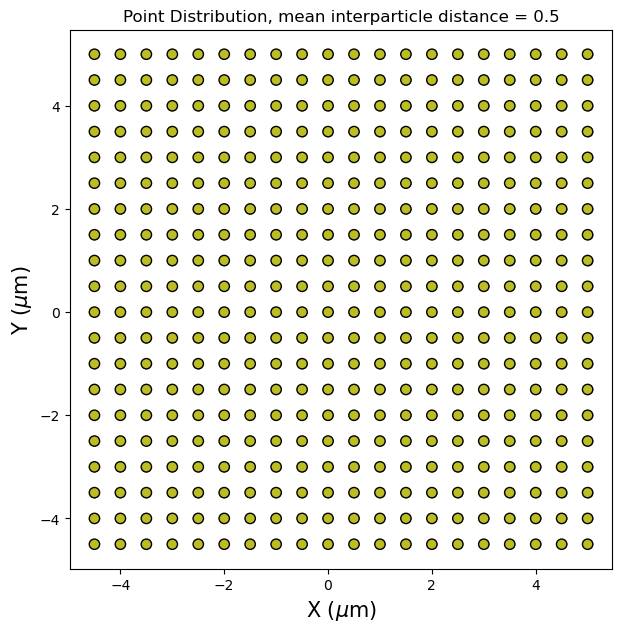

In [6]:
Fig = tost.Visualize(lattice)

Fig.plot_distribution()

---

Similarly, other distributions can be obtained. Here, we show a perturbed hexagonal lattice.

In [7]:
lattice = system.hex_lattice(noise = 0.3, #uniform un-correlated noise at each lattice site
                              )

In [6]:
lattice.BoxSize, lattice.totalparticles

([10, 10, 0], 476)

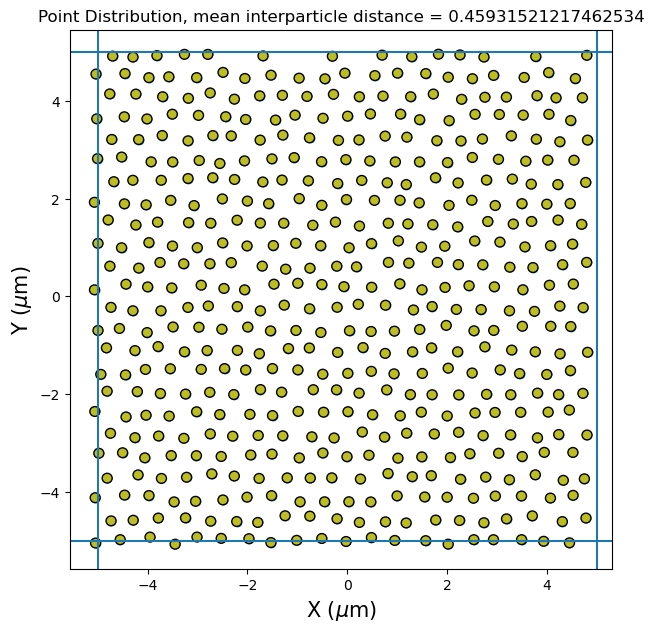

In [9]:
Fig = tost.Visualize(lattice)

ax = Fig.plot_distribution()

# verify the particles are inside the box 
ax.axvline(x=lattice.BoxSize[0]/2) 
ax.axvline(x=-lattice.BoxSize[0]/2)
ax.axhline(y=lattice.BoxSize[1]/2)
ax.axhline(y=-lattice.BoxSize[1]/2)

The same plotting object can be used to visualize the reciprocal space data. For point-distributions, this can be studied by evaluating the non-uniform fourier transform (NU-FFT), namely the _structure factor_, $\tilde{S}(q)$.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


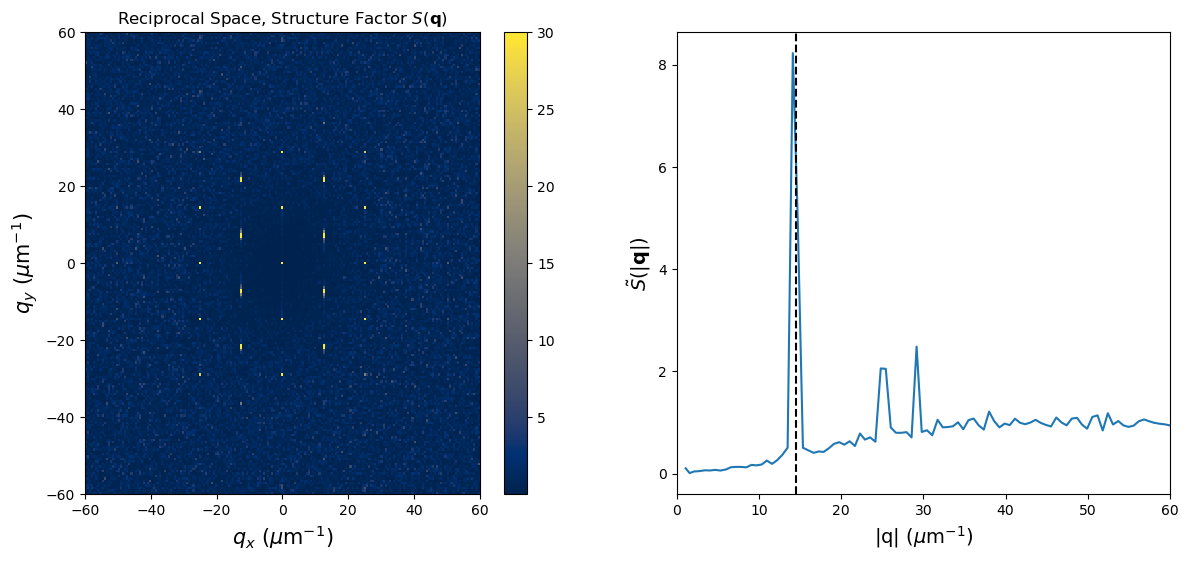

In [8]:
ax = Fig.plot_reciprocal_space(vmax=30)
ax[1].axvline(x=2*np.pi/(system.ax*np.sqrt(3)/2),linestyle='--',color='black')  # ax * (sqrt(3)/2) is the characteristic length 

***

Similarly, a `Phaseprocess` can be defined but now by specifying the resolution of each pixel and the volume fraction. 

Let us define such a phase process in 3D:

In [9]:
system = tost.Phaseprocess(volumefraction=0.6, #fraction of the solid-phase
                      BoxSize=10, # Size of the simulation box (in microns)
                      resolution=0.03, # Resolution of each pixel/voxel (in microns). 
                      interpore_distance=0.4, # mean distance between each empty phase
                      is_3D=True) # 3D or 2D

Taking Lx,Ly,Lz= 10


These properties can be used to either generate a two-phased media from a point-distribution with same properties (inter-pore distance <=> mean interparticle) and trivially put pores at the points, or use excursion sets of gaussian random fields (GRFs) with thresholding set by the defined volume fraction. Here, we use GRFs.

Here, the covariance function used is given by:

$\Large \rho(r) = \frac{\sin(ar)}{(ar)}$,

where $a = 2\pi/$`interpore_distance`.

In [11]:
porous_structure = system.GRF_microstructure(params=np.array([0]))

(334, 334, 334)


3D Data. Plotting for y=5.0 slice


<Axes: title={'center': 'Phase Distribution'}, xlabel='X ($\\mu$m)', ylabel='Z ($\\mu$m)'>

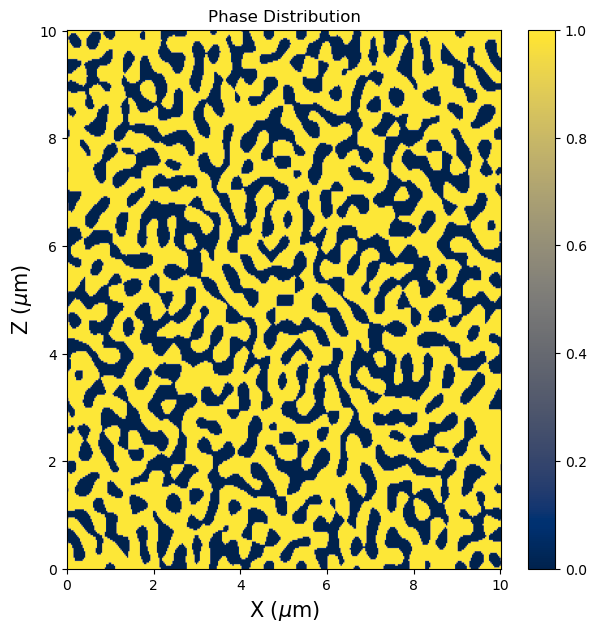

In [12]:
Fig = tost.Visualize(porous_structure)
Fig.plot_distribution(cmap='cividis')

The volume fraction can quickly be verified using the available instances from PhaseDistribution

In [13]:
porous_structure.volumefraction

0.6001668988030608

The reciprocal space for such a media can still be plotted like before, only now, the _structure factor_ $\tilde{S}(q)$ is replaced by its uniform counterpart, the _spectral density_, $\tilde{X}(q)$.

3D data. Plotting for qy=0 slice


[<Axes: title={'center': 'Reciprocal Space'}, xlabel='$q_{x}$ ($\\mu$m$^{-1}$)', ylabel='$q_{y}$ ($\\mu$m$^{-1}$)'>,
 <Axes: xlabel='|q| ($\\mu$m$^{-1}$)', ylabel='$\\tilde{X}(|q|)$'>]

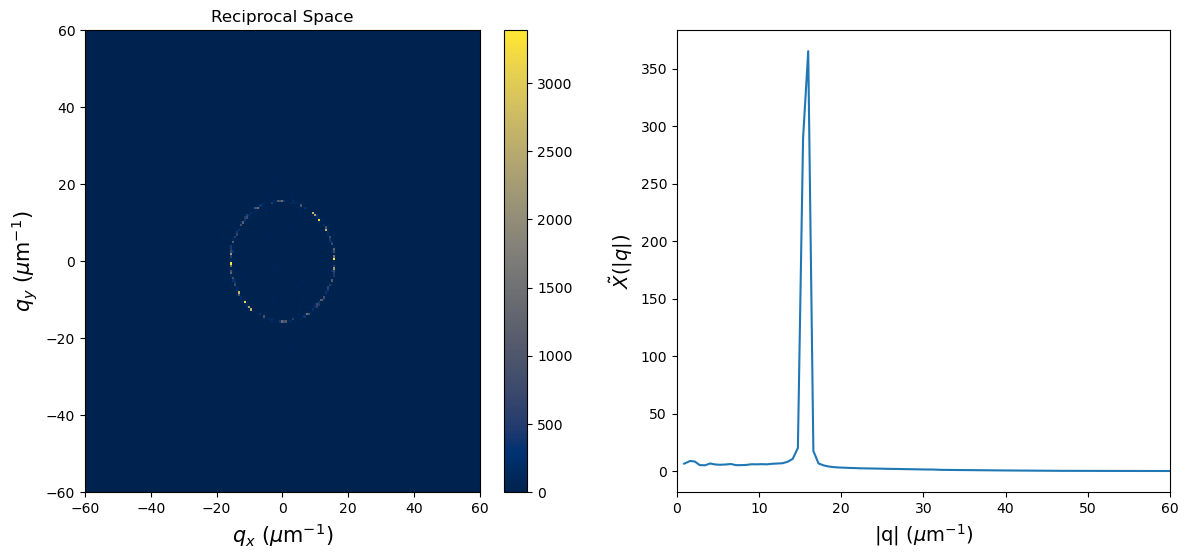

In [12]:
Fig.plot_reciprocal_space(vmax=None)

The real-space correlations can be understood by plotting the auto-covariance $C(r)$ along each principle axes.

<Axes: xlabel='R ($\\mu$m)', ylabel='ACF'>

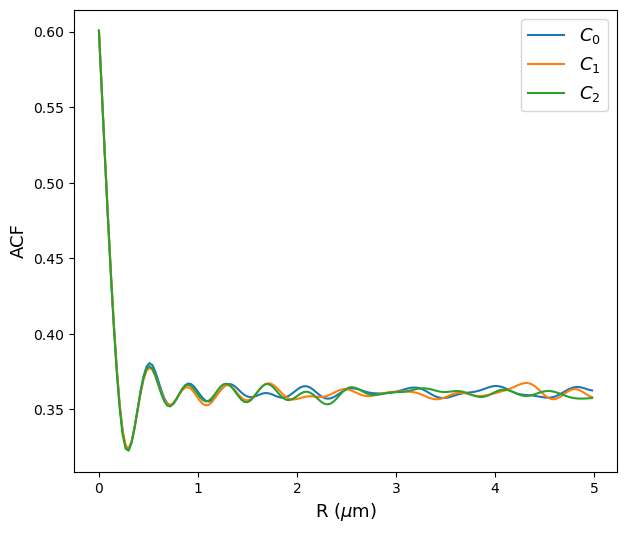

In [ ]:
Fig.plot_principal_ACF(ax=None)

***

Similarly, a 2D phase distribution can be obtained by simply putting `is_3D=False`

In [11]:
system = tost.Phaseprocess(volumefraction=0.7, #fraction of the solid-phase
                      BoxSize=10, # Size of the simulation box (in microns)
                      resolution=0.03, # Resolution of each pixel/voxel (in microns). 
                      interpore_distance=0.4, # mean distance between each empty phase
                      is_3D=False) # 3D or 2D

Taking Lx,Ly,Lz= 10


Let us consider a different distribution of the phases. The covariance function can be modified to be:

$\large \rho(r) = \frac{\sin(ar)}{(ar)} \frac{1}{1+br}$,

where $a = 2\pi/$`interpore_distance`.

In [12]:
porous_structure = system.GRF_microstructure(params=np.array([30,20]),options=['gaussian','hyperbolic']) # refer to Statistics.py for further details.

(334, 334)


<Axes: title={'center': 'Phase Distribution'}, xlabel='X ($\\mu$m)', ylabel='Z ($\\mu$m)'>

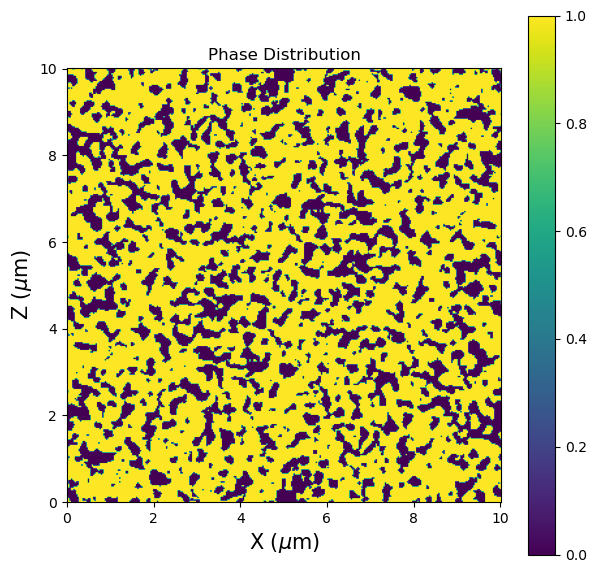

In [17]:
Fig = tost.Visualize(porous_structure)
Fig.plot_distribution()

(334, 334) (334, 334)


[<Axes: title={'center': 'Reciprocal Space, Spectral density $\\tilde{X}(\\mathbf{q})$'}, xlabel='$q_{x}$ ($\\mu$m$^{-1}$)', ylabel='$q_{y}$ ($\\mu$m$^{-1}$)'>,
 <Axes: xlabel='|q| ($\\mu$m$^{-1}$)', ylabel='$\\tilde{X}(|\\mathbf{q}|)$'>]

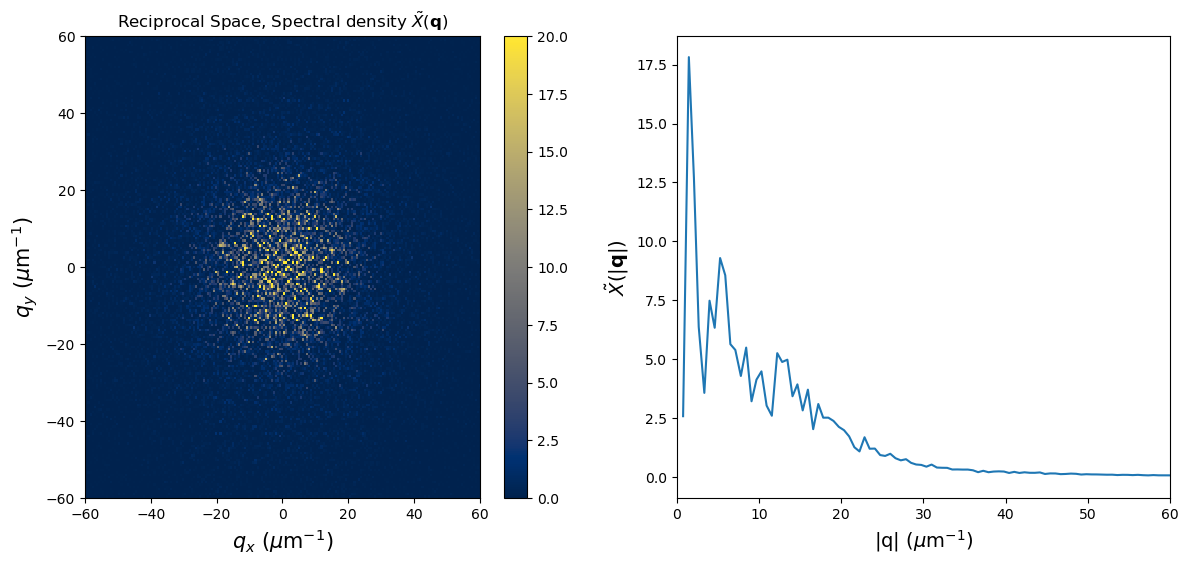

In [18]:
Fig.plot_reciprocal_space(vmax=20)